In [21]:
from __future__ import annotations

import cv2
import json
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from tqdm.auto import tqdm

# Paths
PROJECT_ROOT = Path('..').resolve()
DATASET_ROOT = PROJECT_ROOT / 'dataset'
POSE_CACHE = PROJECT_ROOT / 'artifacts' / 'poses'
BALL_CACHE = PROJECT_ROOT / 'artifacts' / 'ball_tracking'
POSE_MANIFEST_PATH = POSE_CACHE / 'manifest.csv'

# COCO skeleton
COCO_LINKS = [
    (0, 1), (1, 2), (2, 3), (3, 4), (1, 5), (5, 6), (6, 7),
    (1, 8), (8, 9), (9, 10), (10, 11), (8, 12), (12, 13), (13, 14),
    (0, 15), (0, 16)
]
WRIST_INDICES = (9, 10)  # left_wrist, right_wrist


def load_pose_data(pose_path: Path) -> dict:
    """Load pose data from JSON."""
    return json.loads(pose_path.read_text())


def load_ball_track(ball_path: Path) -> dict:
    """Load ball tracking data from JSON."""
    return json.loads(ball_path.read_text())


# Load manifest
if not POSE_MANIFEST_PATH.exists():
    raise FileNotFoundError(f'Pose manifest missing: {POSE_MANIFEST_PATH}')

manifest = pd.read_csv(POSE_MANIFEST_PATH)
manifest['pose_path'] = manifest['pose_path'].apply(Path)

# Add ball_path column
def find_ball_path(pose_path):
    ball_path = BALL_CACHE / f'{pose_path.stem}.json'
    return ball_path if ball_path.exists() else None

manifest['ball_path'] = manifest['pose_path'].apply(find_ball_path)

print(f"{len(manifest)} videos with pose data")
print(f"{manifest['ball_path'].notna().sum()} videos with ball tracking")
manifest.head()

188 videos with pose data
188 videos with ball tracking


,stroke,video,pose_path,ball_path
0,Backhand,108cfa87_IMG_6554_Backhand_f1612-1625.mp4,../artifacts/poses/108cfa87_IMG_6554_Backhand_...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...
1,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,../artifacts/poses/a0136e6b_Di_Nenno_Augsburge...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...
2,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,../artifacts/poses/a0136e6b_Di_Nenno_Augsburge...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...
3,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,../artifacts/poses/a0136e6b_Di_Nenno_Augsburge...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...
4,Backhand,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,../artifacts/poses/a0136e6b_Di_Nenno_Augsburge...,/Users/roberto/Desktop/UNIR-IA/Trabajo-Fin-de-...


## Approach 1: Ball Proximity Voting
Select the player who spends the most time closest to the ball trajectory.

In [22]:
def select_by_ball_proximity(
    frames: List[dict],
    ball_frames: List[dict],
    distance_threshold: float = 200.0,
) -> Optional[int]:
    """
    Select striker based on ball proximity voting.
    
    For each ball detection, vote for the player whose wrists are closest to the ball.
    Player with most votes is selected as striker.
    
    Returns:
        person_idx of selected striker, or None if no clear striker.
    """
    votes = {}  # person_idx -> vote count
    
    for ball_data in ball_frames:
        if ball_data['confidence'] < 0.5:
            continue
        
        frame_idx = ball_data['frame_idx']
        if frame_idx >= len(frames):
            continue
        
        frame = frames[frame_idx]
        if 'keypoints' not in frame or not frame['keypoints']:
            continue
        
        ball_pos = np.asarray(ball_data['center'], dtype=np.float32)
        
        min_dist = float('inf')
        closest_person = None
        
        for person_idx, keypoints in enumerate(frame['keypoints']):
            kpts = np.asarray(keypoints, dtype=np.float32)
            scores = np.asarray(frame['scores'][person_idx], dtype=np.float32) if 'scores' in frame else np.ones(len(kpts))
            
            # Get wrist positions
            wrist_points = []
            for w_idx in WRIST_INDICES:
                if scores[w_idx] > 0.3:
                    wrist_points.append(kpts[w_idx])
            
            if not wrist_points:
                continue
            
            # Min distance to ball from either wrist
            distances = [np.linalg.norm(wrist - ball_pos) for wrist in wrist_points]
            min_wrist_dist = min(distances)
            
            if min_wrist_dist < min_dist:
                min_dist = min_wrist_dist
                closest_person = person_idx
        
        if closest_person is not None and min_dist < distance_threshold:
            votes[closest_person] = votes.get(closest_person, 0) + 1
    
    # Select player with most votes
    return max(votes.items(), key=lambda x: x[1])[0] if votes else None

In [23]:
# Test on first sample with ball tracking
sample = manifest[manifest['ball_path'].notna()].iloc[0]
print(f"Testing on: {sample['pose_path'].stem}")

# Load data
pose_data = load_pose_data(sample['pose_path'])
ball_track = load_ball_track(sample['ball_path'])

print(f"Frames: {len(pose_data['frames'])}")
print(f"Ball detections: {len(ball_track['frames'])}")
print(f"FPS: {pose_data['fps']:.2f}")

# Sample frame structure
if pose_data['frames']:
    first_frame = pose_data['frames'][0]
    print(f"\nFirst frame has {len(first_frame['keypoints'])} people")
    print(f"Each person has {len(first_frame['keypoints'][0])} keypoints")
    
# Test proximity selection
winner = select_by_ball_proximity(pose_data['frames'], ball_track['frames'])
print(f"\nBall proximity winner: Person {winner}")

Testing on: 108cfa87_IMG_6554_Backhand_f1612-1625
Frames: 17
Ball detections: 17
FPS: 29.97

First frame has 3 people
Each person has 17 keypoints

Ball proximity winner: Person 0


## Approach 2: Wrist Velocity + Ball Proximity Fusion
Combine wrist movement speed with ball proximity for more robust selection.

In [29]:
def compute_wrist_velocity(
    frames: List[dict],
    fps: float,
) -> Dict[int, float]:
    """
    Compute average wrist velocity for each person across the sequence.
    
    Returns:
        Dict mapping person_idx to average velocity (pixels/second).
    """
    person_velocities = {}
    person_frame_counts = {}  # Track how many frames each person appears in
    
    # Iterate through frames
    for frame_idx in range(1, len(frames)):
        prev_frame = frames[frame_idx - 1]
        curr_frame = frames[frame_idx]
        
        # Check frames have keypoints
        if 'keypoints' not in prev_frame or 'keypoints' not in curr_frame:
            continue
        
        # Match by index (assume consistent ordering)
        num_people = min(len(prev_frame['keypoints']), len(curr_frame['keypoints']))
        
        for person_idx in range(num_people):
            prev_kpts = np.asarray(prev_frame['keypoints'][person_idx], dtype=np.float32)
            curr_kpts = np.asarray(curr_frame['keypoints'][person_idx], dtype=np.float32)
            
            # Get scores if available
            prev_scores = np.asarray(prev_frame['scores'][person_idx], dtype=np.float32) if 'scores' in prev_frame else np.ones(len(prev_kpts))
            curr_scores = np.asarray(curr_frame['scores'][person_idx], dtype=np.float32) if 'scores' in curr_frame else np.ones(len(curr_kpts))
            
            # Average both wrists
            wrist_points_prev = []
            wrist_points_curr = []
            
            for w_idx in WRIST_INDICES:
                if prev_scores[w_idx] > 0.3 and curr_scores[w_idx] > 0.3:
                    wrist_points_prev.append(prev_kpts[w_idx])
                    wrist_points_curr.append(curr_kpts[w_idx])
            
            if not wrist_points_prev or not wrist_points_curr:
                continue
            
            prev_wrist = np.mean(wrist_points_prev, axis=0)
            curr_wrist = np.mean(wrist_points_curr, axis=0)
            
            velocity = np.linalg.norm(curr_wrist - prev_wrist) * fps
            
            if person_idx not in person_velocities:
                person_velocities[person_idx] = []
                person_frame_counts[person_idx] = 0
            person_velocities[person_idx].append(velocity)
            person_frame_counts[person_idx] += 1
    
    # Only return velocities for people who appear in at least 50% of frames
    min_frames = len(frames) * 0.5
    filtered_velocities = {
        pid: np.mean(vels) 
        for pid, vels in person_velocities.items() 
        if person_frame_counts[pid] >= min_frames
    }
    
    return filtered_velocities


def select_by_velocity(
    frames: List[dict],
    fps: float,
) -> Optional[int]:
    """
    Select striker based purely on wrist velocity.
    
    Player with highest average wrist velocity is selected as striker.
    
    Returns:
        person_idx of selected striker, or None if no velocities computed.
    """
    velocities = compute_wrist_velocity(frames, fps)
    
    if not velocities:
        return None
    
    return max(velocities.items(), key=lambda x: x[1])[0]


def select_by_fusion(
    frames: List[dict],
    ball_frames: List[dict],
    fps: float,
    velocity_weight: float = 0.5,
) -> Optional[int]:
    """
    Select striker by fusing wrist velocity and ball proximity scores.
    
    Higher wrist velocity + closer to ball = higher score.
    
    Returns:
        person_idx of selected striker, or None if no clear striker.
    """
    # Compute wrist velocities
    velocities = compute_wrist_velocity(frames, fps)
    
    # Normalize velocities to [0, 1]
    if velocities:
        max_vel = max(velocities.values())
        velocities = {pid: v / max_vel for pid, v in velocities.items()}
    
    # Compute proximity scores
    proximity_scores = {}
    person_frame_counts = {}  # Track how many frames each person appears in
    
    for ball_data in ball_frames:
        if ball_data['confidence'] < 0.5:
            continue
        
        frame_idx = ball_data['frame_idx']
        if frame_idx >= len(frames):
            continue
        
        frame = frames[frame_idx]
        if 'keypoints' not in frame or not frame['keypoints']:
            continue
        
        ball_pos = np.asarray(ball_data['center'], dtype=np.float32)
        
        for person_idx, keypoints in enumerate(frame['keypoints']):
            kpts = np.asarray(keypoints, dtype=np.float32)
            scores = np.asarray(frame['scores'][person_idx], dtype=np.float32) if 'scores' in frame else np.ones(len(kpts))
            
            wrist_points = []
            for w_idx in WRIST_INDICES:
                if scores[w_idx] > 0.3:
                    wrist_points.append(kpts[w_idx])
            
            if not wrist_points:
                continue
            
            distances = [np.linalg.norm(wrist - ball_pos) for wrist in wrist_points]
            min_dist = min(distances)
            
            if person_idx not in proximity_scores:
                proximity_scores[person_idx] = []
                person_frame_counts[person_idx] = 0
            proximity_scores[person_idx].append(min_dist)
            person_frame_counts[person_idx] += 1
    
    # Only keep proximity scores for people who appear in at least 50% of ball frames
    min_ball_frames = len([b for b in ball_frames if b['confidence'] > 0.5]) * 0.5
    proximity_scores = {
        pid: dists 
        for pid, dists in proximity_scores.items() 
        if person_frame_counts[pid] >= min_ball_frames
    }
    
    # Average proximity for each person (invert so closer = higher score)
    proximity_scores = {pid: 1.0 / (1.0 + np.mean(dists)) 
                       for pid, dists in proximity_scores.items()}
    
    # Fuse scores
    all_people = set(velocities.keys()) | set(proximity_scores.keys())
    fused_scores = {}
    
    for person_idx in all_people:
        vel_score = velocities.get(person_idx, 0)
        prox_score = proximity_scores.get(person_idx, 0)
        fused_scores[person_idx] = velocity_weight * vel_score + (1 - velocity_weight) * prox_score
    
    return max(fused_scores.items(), key=lambda x: x[1])[0] if fused_scores else None


# Test all three approaches
sample_with_ball = manifest[manifest['ball_path'].notna()].iloc[0]
test_pose = load_pose_data(sample_with_ball['pose_path'])
test_ball = load_ball_track(sample_with_ball['ball_path'])

winner_prox = select_by_ball_proximity(test_pose['frames'], test_ball['frames'])
winner_vel = select_by_velocity(test_pose['frames'], test_pose['fps'])
winner_fusion = select_by_fusion(test_pose['frames'], test_ball['frames'], test_pose['fps'])

print(f"Video: {sample_with_ball['video']}")
print(f"Proximity winner:     Person {winner_prox}")
print(f"Velocity winner:      Person {winner_vel}")
print(f"Fusion winner:        Person {winner_fusion}")


Video: 108cfa87_IMG_6554_Backhand_f1612-1625.mp4
Proximity winner:     Person 0
Velocity winner:      Person 0
Fusion winner:        Person 0


## Batch Comparison
Compare both approaches across multiple videos.

In [30]:
def compare_approaches(manifest: pd.DataFrame, num_samples: int = 20) -> pd.DataFrame:
    """Compare all three approaches across videos."""
    results = []
    
    # Only process videos with ball tracking
    samples = manifest[manifest['ball_path'].notna()].head(num_samples)
    
    for row in tqdm(samples.itertuples(index=False), total=len(samples)):
        pose_data = load_pose_data(row.pose_path)
        ball_track = load_ball_track(row.ball_path)
        
        frames = pose_data['frames']
        fps = pose_data['fps']
        
        prox_winner = select_by_ball_proximity(frames, ball_track['frames'])
        vel_winner = select_by_velocity(frames, fps)
        fusion_winner = select_by_fusion(frames, ball_track['frames'], fps)
        
        results.append({
            'video': row.video,
            'stroke': row.stroke,
            'proximity': prox_winner,
            'velocity': vel_winner,
            'fusion': fusion_winner,
            'prox_vel_agree': prox_winner == vel_winner if prox_winner is not None and vel_winner is not None else None,
            'prox_fusion_agree': prox_winner == fusion_winner if prox_winner is not None and fusion_winner is not None else None,
            'vel_fusion_agree': vel_winner == fusion_winner if vel_winner is not None and fusion_winner is not None else None,
            'all_agree': prox_winner == vel_winner == fusion_winner if all(x is not None for x in [prox_winner, vel_winner, fusion_winner]) else None,
        })
    
    return pd.DataFrame(results)


# Run comparison
comparison = compare_approaches(manifest, num_samples=20)
print(f"\n{'='*60}")
print(f"COMPARISON RESULTS ({len(comparison)} videos)")
print(f"{'='*60}")
print(f"All three agree:           {comparison['all_agree'].sum()}/{len(comparison)} ({comparison['all_agree'].sum() / len(comparison):.1%})")
print(f"Proximity-Velocity agree:  {comparison['prox_vel_agree'].sum()}/{len(comparison)} ({comparison['prox_vel_agree'].sum() / len(comparison):.1%})")
print(f"Proximity-Fusion agree:    {comparison['prox_fusion_agree'].sum()}/{len(comparison)} ({comparison['prox_fusion_agree'].sum() / len(comparison):.1%})")
print(f"Velocity-Fusion agree:     {comparison['vel_fusion_agree'].sum()}/{len(comparison)} ({comparison['vel_fusion_agree'].sum() / len(comparison):.1%})")
print(f"\nSuccessful selections:")
print(f"  Proximity: {comparison['proximity'].notna().sum()}")
print(f"  Velocity:  {comparison['velocity'].notna().sum()}")
print(f"  Fusion:    {comparison['fusion'].notna().sum()}")
comparison

  0%|          | 0/20 [00:00<?, ?it/s]


COMPARISON RESULTS (20 videos)
All three agree:           6/20 (30.0%)
Proximity-Velocity agree:  6/20 (30.0%)
Proximity-Fusion agree:    6/20 (30.0%)
Velocity-Fusion agree:     20/20 (100.0%)

Successful selections:
  Proximity: 17
  Velocity:  20
  Fusion:    20


,video,stroke,proximity,velocity,fusion,prox_vel_agree,prox_fusion_agree,vel_fusion_agree,all_agree
0,108cfa87_IMG_6554_Backhand_f1612-1625.mp4,Backhand,0.0,0,0,True,True,True,True
1,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,Backhand,3.0,1,1,False,False,True,False
2,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,Backhand,2.0,2,2,True,True,True,True
3,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,Backhand,NaN,1,1,None,None,True,None
4,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,Backhand,3.0,0,0,False,False,True,False
5,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,Backhand,0.0,1,1,False,False,True,False
6,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,Backhand,1.0,0,0,False,False,True,False
7,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,Backhand,2.0,2,2,True,True,True,True
8,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,Backhand,0.0,0,0,True,True,True,True
9,a0136e6b_Di_Nenno_Augsburger_vs_Garcia_Barahon...,Backhand,1.0,3,3,False,False,True,False


## Visualization
Display skeleton overlays with winner highlighted for both approaches.

Visualizing selections across different stroke types...



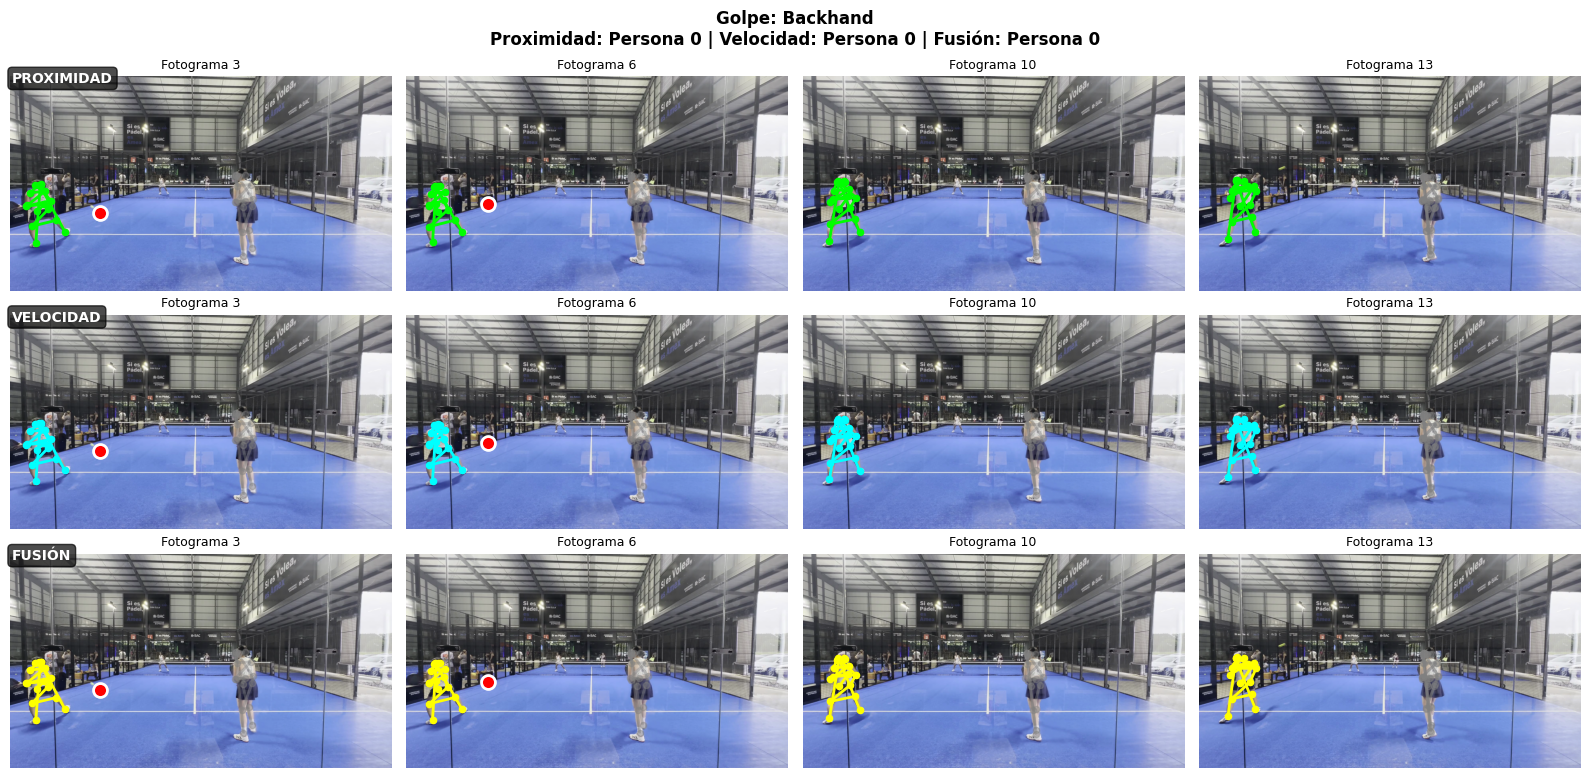

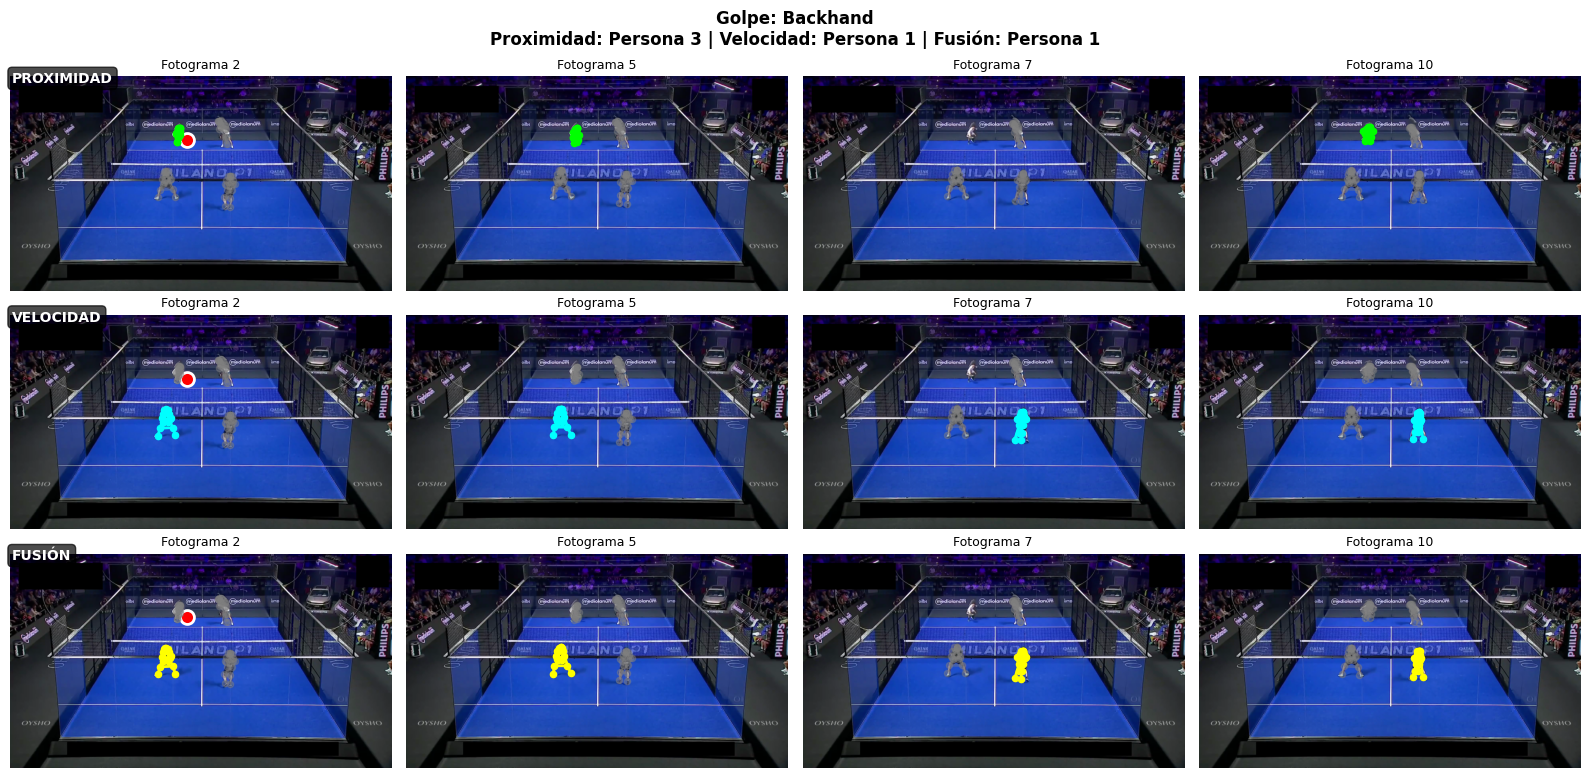

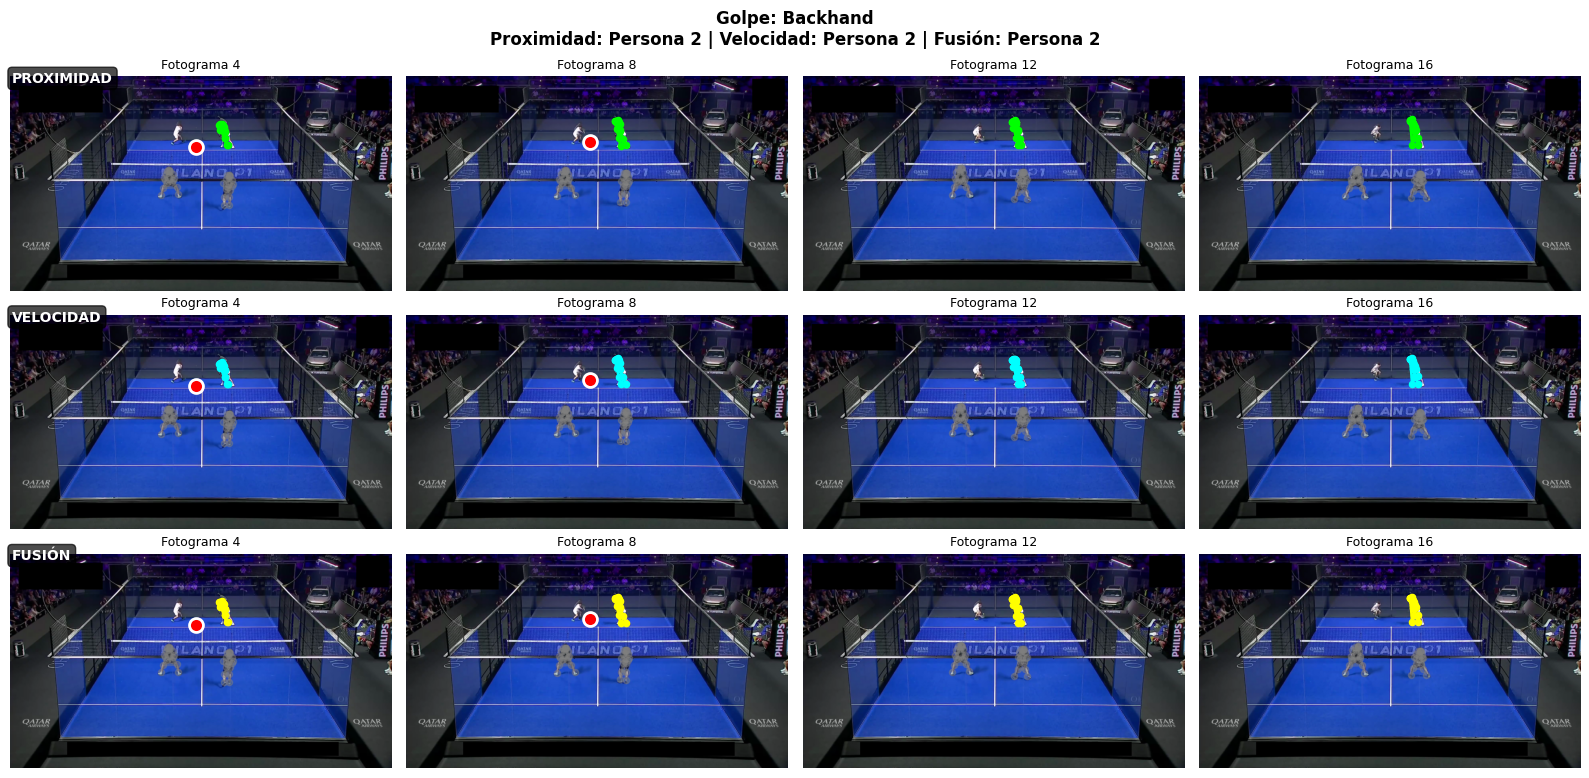

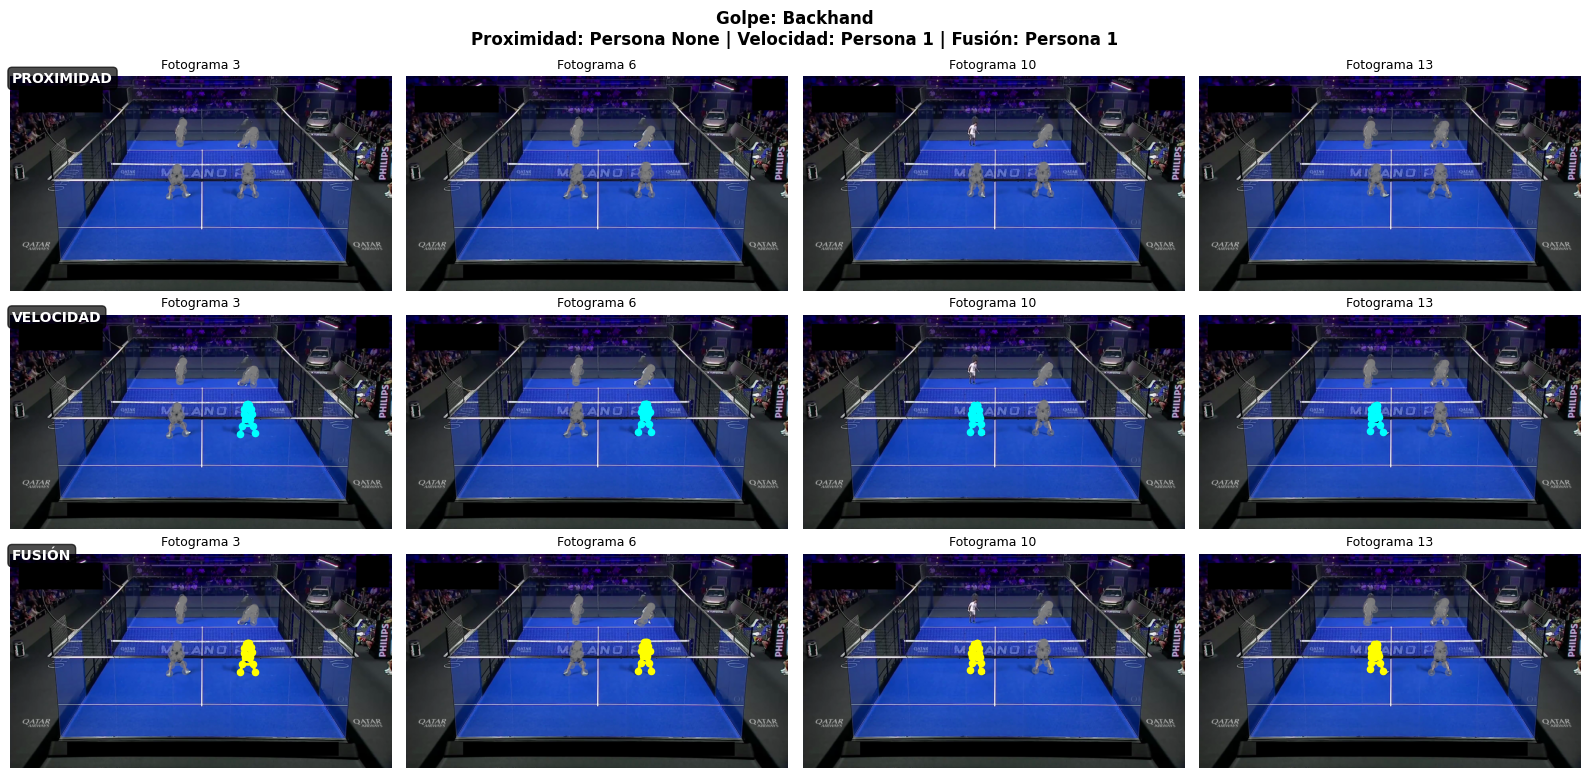

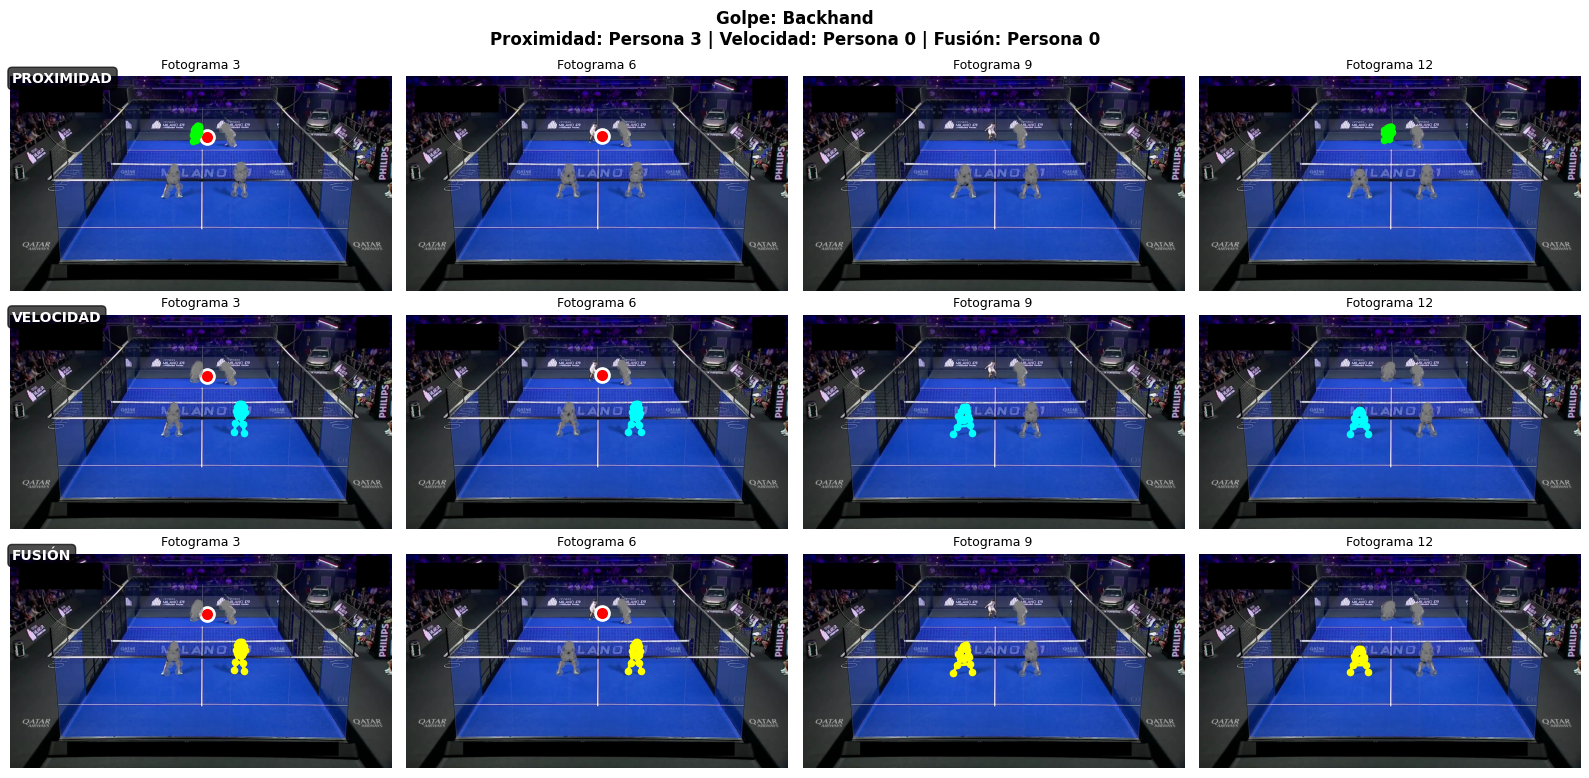

In [38]:
def visualize_selection(
    video_name: str,
    pose_data: dict,
    ball_track: dict,
    stroke_type: str,
) -> None:
    """Visualize all three selection approaches on sample frames."""
    frames = pose_data['frames']
    fps = pose_data['fps']
    ball_frames = ball_track['frames']
    
    # Get video path
    video_row = manifest[manifest['video'] == video_name].iloc[0]
    video_path = DATASET_ROOT / video_row['stroke'] / video_name
    
    # Compute winners for all three approaches
    prox_winner = select_by_ball_proximity(frames, ball_frames)
    vel_winner = select_by_velocity(frames, fps)
    fusion_winner = select_by_fusion(frames, ball_frames, fps)
    
    # Read video frames
    cap = cv2.VideoCapture(str(video_path))
    all_frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        all_frames.append(frame)
    cap.release()
    
    # Select 4 evenly spaced frames
    frame_indices = [int(i * len(all_frames) / 5) for i in range(1, 5)]
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 8))
    fig.suptitle(f'Golpe: {stroke_type}\nProximidad: Persona {prox_winner} | Velocidad: Persona {vel_winner} | Fusión: Persona {fusion_winner}', fontweight='bold')
    
    for col_idx, frame_idx in enumerate(frame_indices):
        if frame_idx >= len(all_frames):
            continue
        
        img = cv2.cvtColor(all_frames[frame_idx], cv2.COLOR_BGR2RGB)
        pose_frame = frames[frame_idx] if frame_idx < len(frames) else None
        
        # Ball position for this frame
        ball_at_frame = [b for b in ball_frames if b['frame_idx'] == frame_idx]
        
        # Row 1: Proximity approach
        ax_prox = axes[0, col_idx]
        ax_prox.imshow(img)
        
        if pose_frame and 'keypoints' in pose_frame:
            for person_idx, keypoints in enumerate(pose_frame['keypoints']):
                is_winner = (prox_winner is not None and person_idx == prox_winner)
                color = 'lime' if is_winner else 'gray'
                alpha = 1.0 if is_winner else 0.4
                draw_skeleton(ax_prox, keypoints, color, alpha)
        
        if ball_at_frame and ball_at_frame[0]['confidence'] > 0.5:
            ball_pos = ball_at_frame[0]['center']
            ax_prox.scatter(ball_pos[0], ball_pos[1], c='red', s=100, marker='o', edgecolors='white', linewidths=2)
        
        if col_idx == 0:
            ax_prox.text(10, 30, 'PROXIMIDAD', fontsize=10, fontweight='bold', color='white', 
                        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        ax_prox.set_title(f'Fotograma {frame_idx}', fontsize=9)
        ax_prox.axis('off')
        
        # Row 2: Velocity approach
        ax_vel = axes[1, col_idx]
        ax_vel.imshow(img)
        
        if pose_frame and 'keypoints' in pose_frame:
            for person_idx, keypoints in enumerate(pose_frame['keypoints']):
                is_winner = (vel_winner is not None and person_idx == vel_winner)
                color = 'cyan' if is_winner else 'gray'
                alpha = 1.0 if is_winner else 0.4
                draw_skeleton(ax_vel, keypoints, color, alpha)
        
        if ball_at_frame and ball_at_frame[0]['confidence'] > 0.5:
            ball_pos = ball_at_frame[0]['center']
            ax_vel.scatter(ball_pos[0], ball_pos[1], c='red', s=100, marker='o', edgecolors='white', linewidths=2)
        
        if col_idx == 0:
            ax_vel.text(10, 30, 'VELOCIDAD', fontsize=10, fontweight='bold', color='white',
                       bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        ax_vel.set_title(f'Fotograma {frame_idx}', fontsize=9)
        ax_vel.axis('off')
        
        # Row 3: Fusion approach
        ax_fusion = axes[2, col_idx]
        ax_fusion.imshow(img)
        
        if pose_frame and 'keypoints' in pose_frame:
            for person_idx, keypoints in enumerate(pose_frame['keypoints']):
                is_winner = (fusion_winner is not None and person_idx == fusion_winner)
                color = 'yellow' if is_winner else 'gray'
                alpha = 1.0 if is_winner else 0.4
                draw_skeleton(ax_fusion, keypoints, color, alpha)
        
        if ball_at_frame and ball_at_frame[0]['confidence'] > 0.5:
            ball_pos = ball_at_frame[0]['center']
            ax_fusion.scatter(ball_pos[0], ball_pos[1], c='red', s=100, marker='o', edgecolors='white', linewidths=2)
        
        if col_idx == 0:
            ax_fusion.text(10, 30, 'FUSIÓN', fontsize=10, fontweight='bold', color='white',
                          bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        ax_fusion.set_title(f'Fotograma {frame_idx}', fontsize=9)
        ax_fusion.axis('off')
    
    plt.tight_layout()
    plt.show()


def draw_skeleton(ax, keypoints, color, alpha):
    """Draw skeleton on matplotlib axis."""
    kpts = np.asarray(keypoints, dtype=np.float32)
    
    # Draw bones
    lines = []
    for i, j in COCO_LINKS:
        if i < len(kpts) and j < len(kpts):
            lines.append([kpts[i], kpts[j]])
    
    if lines:
        lc = LineCollection(lines, colors=color, linewidths=2, alpha=alpha)
        ax.add_collection(lc)
    
    # Draw joints
    for x, y in kpts:
        ax.scatter(x, y, c=color, s=20, alpha=alpha, zorder=3)


# Visualize multiple sample videos (pick diverse strokes)
print("Visualizing selections across different stroke types...\n")

# Select multiple videos from different stroke types
visualization_samples = []
for stroke in comparison['stroke'].unique()[:5]:  # Get first 5 unique strokes
    stroke_videos = comparison[comparison['stroke'] == stroke]
    if not stroke_videos.empty:
        visualization_samples.append((stroke, stroke_videos.iloc[0]['video']))

# If we have fewer than 5, add more from any stroke
if len(visualization_samples) < 5:
    remaining = comparison[~comparison['video'].isin([v for _, v in visualization_samples])]
    for _, row in remaining.head(5 - len(visualization_samples)).iterrows():
        visualization_samples.append((row['stroke'], row['video']))

# Visualize the samples
for stroke_type, video_name in visualization_samples:
    video_row = manifest[manifest['video'] == video_name].iloc[0]
    pose_data = load_pose_data(video_row['pose_path'])
    ball_track = load_ball_track(video_row['ball_path'])
    
    visualize_selection(video_name, pose_data, ball_track, stroke_type)
    print()
